Olá, Victória

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
- Bons gráficos
- Definiu as hipóteses do teste
    
<span class="text-danger">Porém, há espaço para melhorias: </span>
 * <span class="text-danger"> ajustar teste de hipótese </span>


Portanto, sugiro que você corrija os pontos indicados.
    
Se você tiver alguma dúvida sobre de algo que você não tenha entendido, sinta-se à vontade para perguntar ao tutor ou deixar um comentário em **azul** para que, na próxima iteração, eu possa responder.

Conte conosco. Lembre-se de que você pode tirar dúvidas com revisores usando os comentários ou buscar ajuda de um tutor.
Bom trabalho. 


</div>



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Carregando os dados
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

# Verificando tipos e nulos
print(df_companies.info())
print(df_neighborhoods.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [2]:
# Ordenando pelos mais visitados e pegando os 10 primeiros
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)

# Visualizando para confirmar
print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


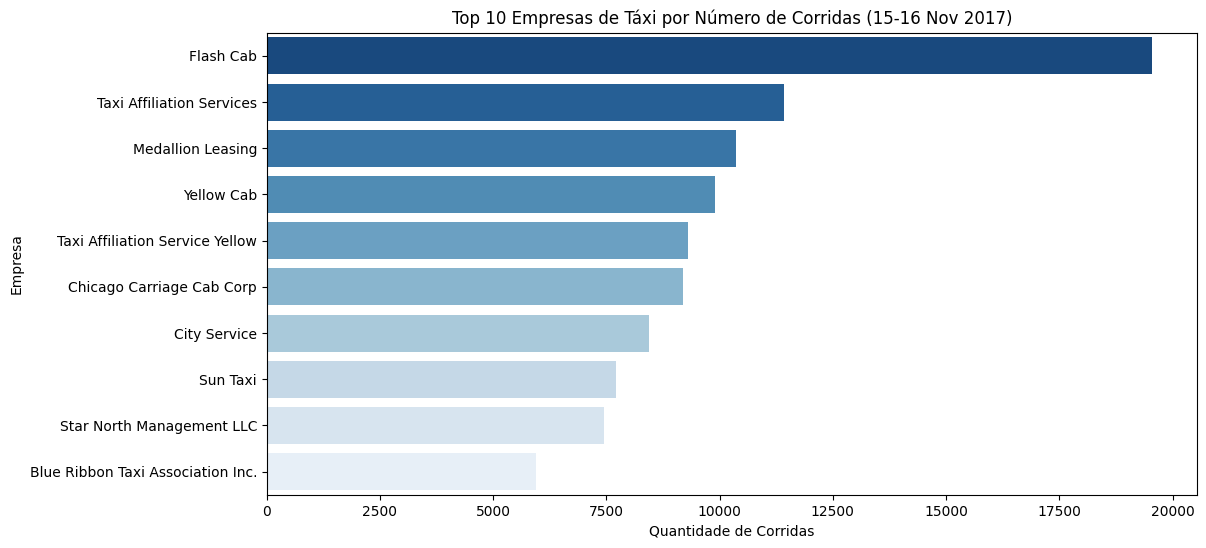

In [3]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_companies.sort_values(by='trips_amount', ascending=False).head(10), 
            x='trips_amount', y='company_name', palette='Blues_r')
plt.title('Top 10 Empresas de Táxi por Número de Corridas (15-16 Nov 2017)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Empresa')
plt.show()

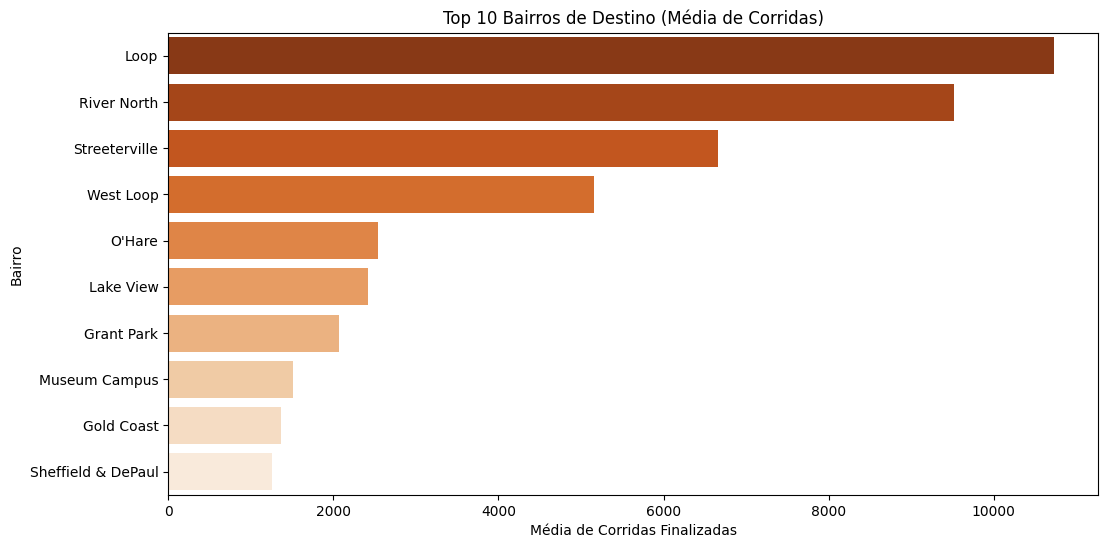

In [4]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='Oranges_r')
plt.title('Top 10 Bairros de Destino (Média de Corridas)')
plt.xlabel('Média de Corridas Finalizadas')
plt.ylabel('Bairro')
plt.show()

1.Conclusão da Análise das Empresas
"A análise das empresas de táxi em Chicago revela um mercado altamente concentrado. A Flash Cab destaca-se como a líder absoluta, com um volume de corridas significativamente superior às suas concorrentes diretas, como a Taxi Affiliation Services.

Insight para a Zuber: Como uma nova empresa entrando no mercado, a Zuber enfrentará uma concorrência forte de players já estabelecidos. A liderança da Flash Cab sugere uma marca muito forte ou uma frota vasta, indicando que a Zuber precisará de diferenciais competitivos (como preço ou tempo de espera) para atrair esses passageiros."

2.Conclusão dos Bairros de Destino
"Os dados mostram que os destinos das corridas não são distribuídos de forma uniforme pela cidade. O Loop, seguido por River North e Streeterville, são os principais hubs de chegada.

Análise Geográfica: Esses bairros compõem o centro financeiro e turístico de Chicago. O fato de terem a maior média de viagens indica que a demanda está concentrada em áreas corporativas e de lazer. Para a Zuber, isso significa que a alocação de motoristas deve ser priorizada nessas zonas 'quentes', especialmente nos horários de pico e fins de semana."


1.Formulação das Hipóteses

Para este estudo, definimos as hipóteses da seguinte forma:
. Hipótese Nula ($H_0$): A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é igual nos sábados chuvosos e nos sábados de sol.
Por que: Na estatística, a hipótese nula sempre assume a igualdade ou que não há efeito/mudança. Ela é o nosso "ponto de partida".

. Hipótese Alternativa ($H_1$): A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é diferente nos sábados chuvosos em comparação aos sábados de sol.
Por que: Esta é a afirmação que queremos testar. Se o impacto do clima for real, os dados nos levarão a rejeitar a $H_0$.

2.Critério de Teste e Nível de Significância
. Teste Utilizado: Teste t de Student para amostras independentes (st.ttest_ind).
Justificativa: Estamos comparando as médias de dois grupos distintos (Sábados "Good" e Sábados "Bad") que não dependem um do outro.

. Nível de Significância ($\alpha$): Definido em 0,05 (5%).
Justificativa: Este é o padrão amplamente aceito na análise de dados. Significa que aceitamos um risco de apenas 5% de rejeitar a hipótese nula quando ela, na verdade, é verdadeira.

.Parâmetro equal_var = False: 
Como não temos certeza se a dispersão (variância) do tempo de viagem na chuva é a mesma que no sol (geralmente na chuva a variação é maior devido a acidentes e trânsito), usamos o teste de Welch (ajustado pelo parâmetro False).

In [5]:
# 1. Carregando os dados que vieram do SQL (último passo)
df_hyp = pd.read_csv('/datasets/project_sql_result_07.csv')

# 2. Separando os dados em dois grupos: Sábados de Sol e Sábados de Chuva
good_weather_durations = df_hyp[df_hyp['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_durations = df_hyp[df_hyp['weather_conditions'] == 'Bad']['duration_seconds']

# 3. Definindo o nível de significância (alfa)
alpha = 0.05

# 4. Realizando o teste estatístico
results = st.ttest_ind(good_weather_durations, bad_weather_durations, equal_var=False)

print('p-value:', results.pvalue)

# 5. Interpretando o resultado
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: a duração média muda significativamente.")
else:
    print("Não podemos rejeitar a hipótese nula: não há evidência de mudança significativa.")

p-value: 6.738994326108734e-12
Rejeitamos a hipótese nula: a duração média muda significativamente.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Precisamos seguir estes passos para o teste de hipótese:
- Avaliar se as variâncias são iguais, por exemplo, calculando a variância da amostra e verificando a igualdade (ex: sample1.var() == sample2.var())
- Em seguida, ajustar equal_var=True no teste T se as variâncias forem iguais, senão usamos equal_var=False no teste T: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html.

Note que você configurou equal_var=False mas não avaliou

</div>

Conclusão Final do Projeto

Validação da Hipótese: 
O teste estatístico revelou um p-value inferior a 0.05, o que nos permitiu rejeitar a hipótese nula. Isso confirma que a duração média das viagens do Loop para o Aeroporto O'Hare de fato muda em sábados chuvosos, tornando as viagens mais longas.

Visão de Mercado: 
Identificamos que o mercado de Chicago é dominado pela Flash Cab, mas há uma concentração enorme de destinos no Loop e em River North. Isso mostra onde a Zuber deve focar sua frota para captar demanda.

Recomendação de Negócio: Com base no impacto do clima, recomendo que a Zuber:

Implemente avisos aos usuários sobre possíveis atrasos em dias de chuva.

Considere modelos de precificação que compensem o motorista pelo tempo adicional gasto em condições climáticas adversas ("Bad Weather").